<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Desafio 3 PLN CEIA Ojeda, Juan
## Modelo de lenguaje con tokenización por caracteres


## Tokenización, modelado y predicciones

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from tensorflow.keras.utils import pad_sequences # se utilizará para padding
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

## Datos

Se emplea el libro "Las crónicas de Narnia: El león, la bruja y el ropero" preprocesado previamente.

Cada linea del archivo es una oración. Esta elección es para mejorar la generación de nuevas secuencias a través del contexto de una oración completa.

In [3]:
# Defino la ruta del archivo
file_path = os.path.join('texto_las-cronicas-de-narnia-el-leon-la-bruja-y-el-ropero_oraciones.txt')
# Leer el contenido del archivo
with open(file_path, 'r', encoding='utf-8') as file:
    file_content = file.read()
# Pasar todo el texto a minúscula
article_text = file_content.lower()
# en article text se encuentra el texto de todo el libro
article_text[:1000]

'las crónicas de narnia:    el leon, la bruja       y el ropero                                             capítulo 1                        lucía investiga en el ropero        había una vez cuatro niños cuyos nombres eran pedro, susana, edmundo y lucía.\nesta historia relata lo que les sucedió cuando, durante la guerra y a causa de los bombardeos, fueron enviados lejos de londres a la casa de un viejo profesor.\néste vivía en medio del campo, a diez millas de la estación más cercana y a dos millas del correo más próximo.\nel profesor no era casado, así es que un ama de llaves, la señora macready, y tres sirvientas atendían su casa. (las sirvientas se llamaban ivy, margarita y betty, pero ellas no intervienen mucho en esta historia.)    el anciano profesor tenía un aspecto curioso, pues su cabello blanco no sólo le cubría la cabeza sino también casi toda la cara.\nlos niños simpatizaron con él al instante, a pesar que lucía, la menor, sintió miedo al verlo por primera vez, y edmundo, 

## Elegir el tamaño del contexto
En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus de texto puede ser considerado un documento en sí mismo y el tamaño de contexto puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.    

In [4]:
# seleccionamos el tamaño de contexto
max_context_size = 100
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)
# la longitud de vocabulario de caracteres es:
print(f'Longitud del vocabulario de caracteres: {len(chars_vocab)}')

Longitud del vocabulario de caracteres: 57


In [5]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

## Tokenizar

In [6]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]
tokenized_text[:10]

[8, 20, 28, 39, 53, 26, 41, 45, 11, 53]

## Organización y estructuración del dataset

Se separa el dataset de entrenamiento y validación.
`p_val` será la proporción del corpus que se reservará para validación
`num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación

In [7]:
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el $N+1$).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

In [8]:
X.shape

(189871, 100)

In [9]:
X[0,:10]

array([ 8, 20, 28, 39, 53, 26, 41, 45, 11, 53])

In [10]:
y[0,:10]

array([20, 28, 39, 53, 26, 41, 45, 11, 53, 20])

In [11]:
vocab_size = len(chars_vocab)

## Definir el modelo

In [12]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

El modelo que se propone como ejemplo consume los índices de los tokens y los transforma en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding` que transforma a índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.

In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
model = Sequential(name="modelo_narnia_SimpleRNN")

model.add(Input(shape=(None,1)))
model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot")))
model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model.summary()

Model: "modelo_narnia_SimpleRNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed (TimeDistr  (None, None, 57)         0         
 ibuted)                                                         
                                                                 
 simple_rnn (SimpleRNN)      (None, None, 200)         51600     
                                                                 
 dense (Dense)               (None, None, 57)          11457     
                                                                 
Total params: 63,057
Trainable params: 63,057
Non-trainable params: 0
_________________________________________________________________


In [15]:
import tensorflow as tf

# Ver dispositivos físicos disponibles
print("Dispositivos detectados:")
for device in tf.config.list_physical_devices():
    print(device)


Dispositivos detectados:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

In [16]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl,patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save("my_model.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True


## Entrenamiento

In [19]:
# fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.
history_ppl = []
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl)], batch_size=512)

Epoch 1/20
371/371 [==============================] - ETA: 0s - loss: 2.1389
 mean perplexity: 7.917012280336015 

Saved new model!
371/371 [==============================] - 91s 245ms/step - loss: 2.1389
Epoch 2/20
371/371 [==============================] - ETA: 0s - loss: 1.9523
 mean perplexity: 7.001411286689215 

Saved new model!
371/371 [==============================] - 94s 254ms/step - loss: 1.9523
Epoch 3/20
371/371 [==============================] - ETA: 0s - loss: 1.8303
 mean perplexity: 6.370943424449295 

Saved new model!
371/371 [==============================] - 89s 241ms/step - loss: 1.8303
Epoch 4/20
371/371 [==============================] - ETA: 0s - loss: 1.7525
 mean perplexity: 6.159273196989849 

Saved new model!
371/371 [==============================] - 92s 248ms/step - loss: 1.7525
Epoch 5/20
371/371 [==============================] - ETA: 0s - loss: 1.7029
 mean perplexity: 5.995972457835212 

Saved new model!
371/371 [==============================] - 89s 2

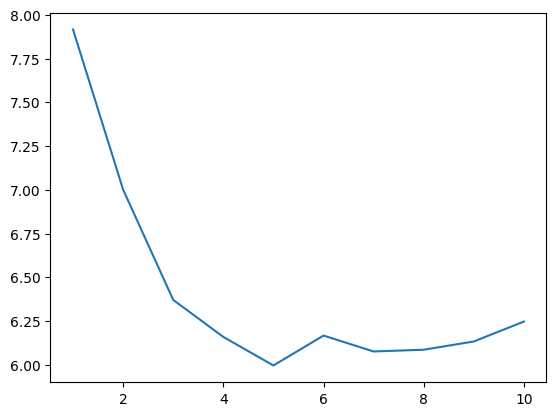

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl)
plt.show()

In [21]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
#model = keras.models.load_model('my_model.keras')

## Predicción del próximo caracter

In [22]:
# Se puede usar gradio para probar el modelo
# Gradio es una herramienta muy útil para crear interfaces para ensayar modelos
# https://gradio.app/

#!pip install -q gradio

In [23]:
# import gradio as gr

# def model_response(human_text):

#     # Encodeamos
#     encoded = [char2idx[ch] for ch in human_text.lower() ]
#     # Si tienen distinto largo
#     encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')

#     # Predicción softmax
#     y_hat = np.argmax(model.predict(encoded)[0,-1,:])


#     # Debemos buscar en el vocabulario el caracter
#     # que corresopnde al indice (y_hat) predicho por le modelo
#     out_word = ''
#     out_word = idx2char[y_hat]

#     # Agrego la palabra a la frase predicha
#     return human_text + out_word

# iface = gr.Interface(
#     fn=model_response,
#     inputs=["textbox"],
#     outputs="text")

# iface.launch(debug=True)

## Generación de secuencias

In [24]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [25]:
input_text='Tumnus'

generate_seq(model, input_text, max_length=max_context_size, n_words=30)

'Tumnus —dijo el castor—.\nes es estab'

## Beam search y muestreo aleatorio

In [26]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [27]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=0.1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens

In [49]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=60,input="sólo en el momento en que estuvieron ", temp=0.1, mode='det')

In [50]:
salidas[0]

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 28, 41,  8, 35, 39,
       47, 45, 39, 47,  8, 39, 25, 35, 25, 47, 45, 29, 35, 39, 47, 45, 39,
       51, 44, 47, 39, 47, 28, 29, 44, 33, 11, 47, 26, 35, 45, 39, 51, 44,
       47, 39, 47,  8, 39, 28, 47, 36, 35, 26, 39, 29, 44, 25, 45, 44, 28,
       24, 39, 34, 47, 15, 53,  8, 20, 25, 41, 39, 28, 44, 28, 20, 45, 20,
       23, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39,
       39, 39, 39, 39, 39, 39, 39])

In [51]:
# veamos las salidas
print(decode(salidas[0]))

fffffffffffffffffffffffffffffffffffffffffffffffffffffffffffffffsólo en el momento en que estuvieron que el señor tumnus! —exclamó susana.                       


In [58]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=60,input="sólo en el momento en que estuvieron ", temp=0.1, mode='sto')
print(decode(salidas[0]))

fffffffffffffffffffffffffffffffffffffffffffffffffffffffffffffffsólo en el momento en que estuvieron a su cara de la bruja blanca de la bruja blanca de la bruja 


In [59]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=60,input="sólo en el momento en que estuvieron ", temp=1, mode='sto')
print(decode(salidas[0]))

fffffffffffffffffffffffffffffffffffffffffffffffffffffffffffffffsólo en el momento en que estuvieron de la bruja blanca.
la bruja blanca de la bruja.
edmundo y d


In [60]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=60,input="sólo en el momento en que estuvieron ", temp=100, mode='sto')
print(decode(salidas[0]))

fffffffffffffffffffffffffffffffffffffffffffffffffffffffffffffffsólo en el momento en que estuvieron nr..ptn0dbnyft;ó-dóznguet0«ló¡2f
5z)
yéa»;aa,ppeoq-0í«prutd3


## Conclusión

Se implementó una red neuronal recurrente tipo Elman utilizando una capa `SimpleRNN` con 200 unidades ocultas para modelar texto a nivel carácter sobre el corpus *Las Crónicas de Narnia: El león, la bruja y el ropero*. La red empleó codificación one-hot mediante `CategoryEncoding`, seguida de una capa densa con activación `softmax` para realizar predicciones sobre el vocabulario.

Durante las pruebas de generación, se observaron limitaciones claras en la capacidad del modelo para mantener coherencia y evitar repeticiones. En el modo determinista (greedy), la red tiende a estancarse en secuencias reiterativas y poco variadas. En el muestreo estocástico, se evidenció que con baja temperatura (p. ej., 0.1), el modelo entra en bucles, y con temperatura alta (p. ej., 100), la salida se vuelve completamente incoherente. Adicionalmente, la aparición sistemática de caracteres 'f' se debe a la codificación de padding.

Si bien se consideró la posibilidad de apilar múltiples capas `SimpleRNN`, se decidió preservar esta arquitectura como referencia base y avanzar hacia un modelo más robusto basado en celdas LSTM, que permitan capturar mejor las dependencias a largo plazo y mejorar la calidad del texto generado.
